In [4]:
import matplotlib.pyplot as plt
import torch
import torchvision

from torch import nn
from torchvision import transforms
from helper_functions import set_seeds

In [5]:
# import splitfolders

# splitfolders.ratio("cartoon", output="dataset",
#     seed=42, ratio=(.7, .2, .1), group_prefix=None, move=False)

In [6]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [7]:
# 1. Get pretrained weights for ViT-Base
pretrained_vit_weights = torchvision.models.ViT_B_16_Weights.DEFAULT 

# 2. Setup a ViT model instance with pretrained weights
pretrained_vit = torchvision.models.vit_b_16(weights=pretrained_vit_weights).to(device)

# 3. Freeze the base parameters
for parameter in pretrained_vit.parameters():
    parameter.requires_grad = False
    
# 4. Change the classifier head 
class_names = ['Snow White','anna','ariel', 'arura','belle','donald','elsa','jasmine','merida','mickey','minion','olaf','pooh','pumba','ruponzel','tiana']


set_seeds()
pretrained_vit.heads = nn.Linear(in_features=768, out_features=len(class_names)).to(device)
# pretrained_vit # uncomment for model output 

In [8]:
from torchinfo import summary

# Print a summary using torchinfo (uncomment for actual output)
summary(model=pretrained_vit, 
        input_size=(32, 3, 224, 224), # (batch_size, color_channels, height, width)
        # col_names=["input_size"], # uncomment for smaller output
        col_names=["input_size", "output_size", "num_params", "trainable"],
        col_width=20,
        row_settings=["var_names"]
)

D:\anaconda\lib\site-packages\torch\nn\modules\activation.py:1230: UserWarning: 1Torch was not compiled with flash attention. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\native\transformers\cuda\sdp_utils.cpp:555.)
  return torch._native_multi_head_attention(


Layer (type (var_name))                                      Input Shape          Output Shape         Param #              Trainable
VisionTransformer (VisionTransformer)                        [32, 3, 224, 224]    [32, 16]             768                  Partial
├─Conv2d (conv_proj)                                         [32, 3, 224, 224]    [32, 768, 14, 14]    (590,592)            False
├─Encoder (encoder)                                          [32, 197, 768]       [32, 197, 768]       151,296              False
│    └─Dropout (dropout)                                     [32, 197, 768]       [32, 197, 768]       --                   --
│    └─Sequential (layers)                                   [32, 197, 768]       [32, 197, 768]       --                   False
│    │    └─EncoderBlock (encoder_layer_0)                   [32, 197, 768]       [32, 197, 768]       (7,087,872)          False
│    │    └─EncoderBlock (encoder_layer_1)                   [32, 197, 768]       [32, 

#### Notice how only the output layer is trainable, where as, all of the rest of the layers are untrainable (frozen).

In [9]:
# Setup directory paths to train and test images
train_dir = 'dataset/train'
test_dir = 'dataset/test'
val_dir = 'dataset/val'

Remember, if you're going to use a pretrained model, it's generally important to ensure your own custom data is transformed/formatted in the same way the data the original model was trained on.

In [10]:
# Get automatic transforms from pretrained ViT weights
pretrained_vit_transforms = pretrained_vit_weights.transforms()
print(pretrained_vit_transforms)

ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)


## And now we've got transforms ready, we can turn our images into DataLoaders using the create_dataloaders()

In [11]:
import os

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

NUM_WORKERS = os.cpu_count()

def create_dataloaders(
    train_dir: str, 
    test_dir: str, 
    val_dir: str,
    transform: transforms.Compose, 
    batch_size: int, 
    num_workers: int=NUM_WORKERS
):

  # Use ImageFolder to create dataset(s)
  train_data = datasets.ImageFolder(train_dir, transform=transform)
  test_data = datasets.ImageFolder(test_dir, transform=transform)
  val_data = datasets.ImageFolder(val_dir, transform=transform)

  # Get class names
  class_names = train_data.classes

  # Turn images into data loaders
  train_dataloader = DataLoader(
      train_data,
      batch_size=batch_size,
      shuffle=True,
      num_workers=num_workers,
      pin_memory=True,
  )
  test_dataloader = DataLoader(
      test_data,
      batch_size=batch_size,
      shuffle=False,
      num_workers=num_workers,
      pin_memory=True,
  )
  val_dataloader = DataLoader(
      val_data,
      batch_size=batch_size,
      shuffle=False,
      num_workers=num_workers,
      pin_memory=True,
  )

    

  return train_dataloader, test_dataloader, val_dataloader, class_names

In [12]:
# Setup dataloaders
train_dataloader_pretrained, test_dataloader_pretrained, val_dataloader_pretrained, class_names = create_dataloaders(train_dir=train_dir,
                                                                                                     test_dir=test_dir,
                                                                                                                     val_dir=val_dir,
                                                                                                     transform=pretrained_vit_transforms,
                                                                                                     batch_size=32) # Could increase if we had more samples, such as here: https://arxiv.org/abs/2205.01580 (there are other improvements there too...)


In [10]:
val_dataloader_pretrained.dataset

Dataset ImageFolder
    Number of datapoints: 1101
    Root location: dataset/val
    StandardTransform
Transform: ImageClassification(
               crop_size=[224]
               resize_size=[256]
               mean=[0.485, 0.456, 0.406]
               std=[0.229, 0.224, 0.225]
               interpolation=InterpolationMode.BILINEAR
           )

In [ ]:
# import matplotlib.pyplot as plt
# import os
# from PIL import Image

# def display_9_images_from_different_classes(dataset_path, class_names):
#     # Dictionary to store one image per class
#     class_images = {}
    
#     # Iterate through classes and find an image for each
#     for class_name in class_names:
#         class_path = os.path.join(dataset_path, class_name)  # Path to the class folder
#         if os.path.isdir(class_path):  # Check if the class folder exists
#             for filename in os.listdir(class_path):
#                 if filename.endswith(('.jpg', '.jpeg', '.png')):  # Check for image files
#                     image_path = os.path.join(class_path, filename)
#                     class_images[class_name] = image_path  # Store the image path
#                     break  # Move to the next class once an image is found
#         if len(class_images) == 9:  # Limit to 9 images
#             break

#     # Plot the images
#     plt.figure(figsize=(10, 10))
#     for i, (class_label, image_path) in enumerate(class_images.items()):
#         plt.subplot(3, 3, i + 1)
#         img = Image.open(image_path)
#         plt.imshow(img)
#         plt.title(class_label)
#         plt.axis('off')

#     plt.tight_layout()
#     plt.show()

# # Example usage:

# display_9_images_from_different_classes(train_dir, class_names)

In [ ]:
from going_modular.going_modular import engine

# Create optimizer and loss function
optimizer = torch.optim.Adam(params=pretrained_vit.parameters(), 
                             lr=1e-3)
loss_fn = torch.nn.CrossEntropyLoss()

# Train the classifier head of the pretrained ViT feature extractor model
set_seeds()
pretrained_vit_results = engine.train(model=pretrained_vit,
                                      train_dataloader=train_dataloader_pretrained,
                                      test_dataloader=val_dataloader_pretrained,
                                      optimizer=optimizer,
                                      loss_fn=loss_fn,
                                      epochs=20,
                                      device=device)

  0%|          | 0/20 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 1.3021 | train_acc: 0.6647 | test_loss: 0.8241 | test_acc: 0.8046
Epoch: 2 | train_loss: 0.6421 | train_acc: 0.8522 | test_loss: 0.6388 | test_acc: 0.8505
Epoch: 3 | train_loss: 0.4899 | train_acc: 0.8886 | test_loss: 0.5632 | test_acc: 0.8675
Epoch: 4 | train_loss: 0.4093 | train_acc: 0.9029 | test_loss: 0.5273 | test_acc: 0.8693
Epoch: 5 | train_loss: 0.3529 | train_acc: 0.9180 | test_loss: 0.5018 | test_acc: 0.8734
Epoch: 6 | train_loss: 0.3108 | train_acc: 0.9319 | test_loss: 0.4808 | test_acc: 0.8805
Epoch: 7 | train_loss: 0.2766 | train_acc: 0.9393 | test_loss: 0.4677 | test_acc: 0.8867
Epoch: 8 | train_loss: 0.2519 | train_acc: 0.9449 | test_loss: 0.4640 | test_acc: 0.8876
Epoch: 9 | train_loss: 0.2293 | train_acc: 0.9498 | test_loss: 0.4576 | test_acc: 0.8930
Epoch: 10 | train_loss: 0.2099 | train_acc: 0.9554 | test_loss: 0.4541 | test_acc: 0.8859
Epoch: 11 | train_loss: 0.1986 | train_acc: 0.9575 | test_loss: 0.4407 | test_acc: 0.8930
Epoch: 12 | train_l

pretrained ViT performed far better than our custom ViT model trained from scratch (in the same amount of time).


In [ ]:
# Example: Save training results alongside the model
training_results = {
    "train_loss": pretrained_vit_results['train_loss'],
    "test_loss": pretrained_vit_results['test_loss'],
    "train_acc": pretrained_vit_results['train_acc'],
    "test_acc": pretrained_vit_results['test_acc']
}

# Save the model and results
torch.save(pretrained_vit.state_dict(), 'saved_model/pretrained_vit_trained_model.pth')
torch.save(training_results, 'saved_model/training_results.pth')

In [14]:
# Load the model weights
pretrained_vit.load_state_dict(torch.load('saved_model/pretrained_vit_trained_model.pth'))

# Load the training results
training_results = torch.load('saved_model/training_results.pth')

# # Now you can access the training results
# train_losses = training_results["train_loss"]
# test_losses = training_results["test_loss"]
# train_accuracies = training_results["train_acc"]
# test_accuracies = training_results["test_acc"]

# # Example: Print the results
# print(f"Train Losses: {train_losses}")
# print(f"Test Losses: {test_losses}")
# print(f"Train Accuracies: {train_accuracies}")
# print(f"Test Accuracies: {test_accuracies}")


C:\Users\allis\AppData\Local\Temp\ipykernel_85352\2966287983.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  pretrained_vit.load_state_dict(torch.load('saved_model/pretr

In [15]:
# Reinitialize the model architecture
# model = pretrained_vit  # Replace with the correct initialization

# # Load the state_dict
# model.load_state_dict(torch.load('saved_model/pretrained_vit_trained_model.pth'))

# Move the model to the appropriate device
pretrained_vit.to(device)
print("Model state dictionary loaded successfully!")


Model state dictionary loaded successfully!


In [16]:
import matplotlib.pyplot as plt
def plot_loss_curves(results):
    """Plots training curves of a results dictionary."""
    # Ensure required keys are present in the results dictionary
    required_keys = ["train_loss", "test_loss", "train_acc", "test_acc"]
    if not all(key in results for key in required_keys):
        raise ValueError(f"Results dictionary must contain the following keys: {required_keys}")

    # Extracting data from the results dictionary
    loss = results["train_loss"]
    test_loss = results["test_loss"]
    accuracy = results["train_acc"]
    test_accuracy = results["test_acc"]

    # Number of epochs is based on the length of the train_loss (assuming they all have the same length)
    epochs = range(len(loss))

    # Create the plot
    plt.figure(figsize=(15, 7))

    # Plot loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, loss, label="train_loss", color='blue')
    plt.plot(epochs, test_loss, label="test_loss", color='red')
    plt.title("Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)

    # Plot accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs, accuracy, label="train_accuracy", color='blue')
    plt.plot(epochs, test_accuracy, label="test_accuracy", color='red')
    plt.title("Accuracy")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)

    # Show the plots
    plt.tight_layout()  # Ensures better layout for the subplots
    plt.show()




In [17]:
training_results

{'train_loss': [1.3020628238799141,
  0.6420748734571895,
  0.4899329375780997,
  0.40933171830704956,
  0.35292006958825667,
  0.3107543184620435,
  0.2765547541870934,
  0.2519268852765443,
  0.22927651537551744,
  0.20985932733489537,
  0.19862254226549728,
  0.18355513898442027,
  0.17024815198583682,
  0.1589894258898118,
  0.14691246157420462,
  0.1420543608484698,
  0.13436573595724632,
  0.12446681378775688,
  0.1179623799856569,
  0.11423696611137664],
 'test_loss': [0.8241063020059041,
  0.6388101498995509,
  0.563237795659474,
  0.5273074239492417,
  0.5017889805138112,
  0.48081509524158067,
  0.4677084750362805,
  0.46396007532519956,
  0.45764194838702676,
  0.4541111722588539,
  0.44071379745645184,
  0.4422621569995369,
  0.44391438508672376,
  0.44563161368880955,
  0.4431999492325953,
  0.43707209607320174,
  0.4413037593343428,
  0.448466354023133,
  0.44348470770886966,
  0.44725460303681236],
 'train_acc': [0.664702868852459,
  0.852202868852459,
  0.88857581967213

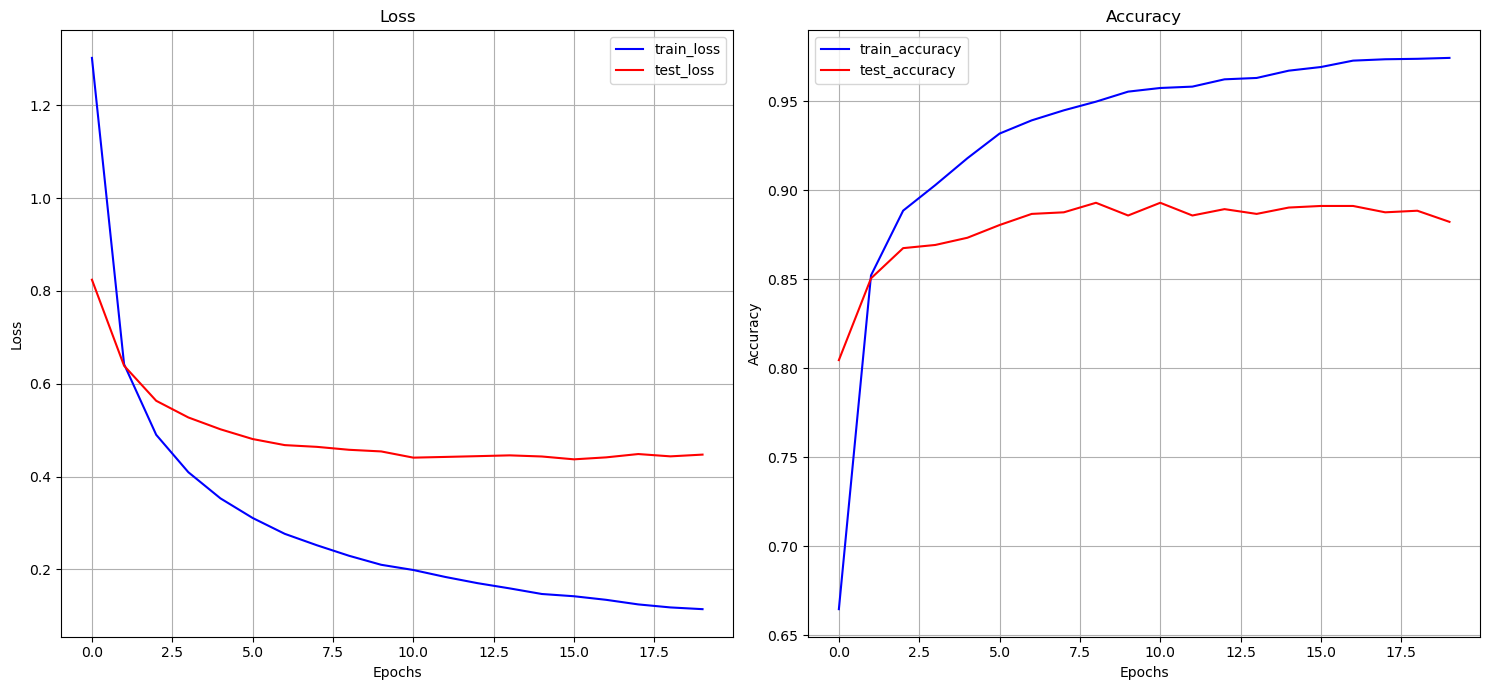

In [18]:
results = {
    "train_loss": [0.6, 0.5, 0.4, 0.3],
    "test_loss": [0.7, 0.6, 0.5, 0.45],
    "train_acc": [0.7, 0.8, 0.85, 0.9],
    "test_acc": [0.65, 0.75, 0.8, 0.85]
}
plot_loss_curves(training_results)

## That's the power of transfer learning!

We managed to get outstanding results with the same model architecture, except our custom implementation was trained from scratch (worse performance) and this feature extractor model has the power of pretrained weights from ImageNet behind it.

# Let's make Prediction:

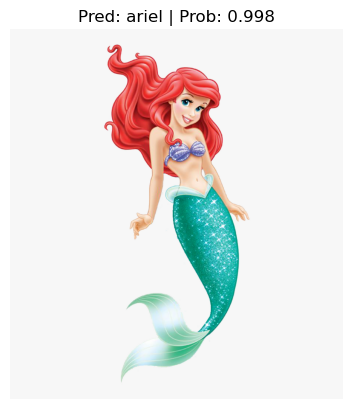

In [19]:
import requests

# Import function to make predictions on images and plot them 
from going_modular.going_modular.predictions import pred_and_plot_image

# Setup custom image path
custom_image_path = "dataset/val/ariel/180-1805538_transparent-little-mermaid-birthday-clipart-arie.png"

# Predict on custom image
pred_and_plot_image(model=pretrained_vit,
                    image_path=custom_image_path,
                    class_names=class_names)

In [ ]:
# Import function to make predictions on images and plot them 
from going_modular.going_modular.predictions import pred_and_plot_image

# Setup custom image path
custom_image_path = "dataset/val/minion/1479351.jpg"

# Predict on custom image
pred_and_plot_image(model=pretrained_vit,
                    image_path=custom_image_path,
                    class_names=class_names)

In [24]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt
import numpy as np

In [21]:
import torch

# Set the model to evaluation mode
pretrained_vit.eval()

# Store predictions and true labels
all_predictions = []
all_labels = []

# Iterate through the test data loader
with torch.no_grad():
    for inputs, labels in val_dataloader_pretrained:
        inputs, labels = inputs.to(device), labels.to(device)  # Move to device
        outputs = pretrained_vit(inputs)  # Get predictions
        _, predictions = torch.max(outputs, 1)  # Get predicted class indices

        all_predictions.extend(predictions.cpu().numpy())  # Store predictions
        all_labels.extend(labels.cpu().numpy())  # Store true labels

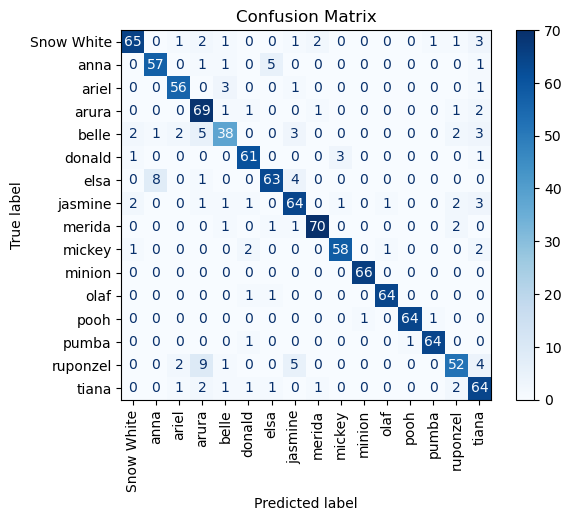

In [22]:
# Generate confusion matrix
cm = confusion_matrix(all_labels, all_predictions)

# Display confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues)  # You can customize the colormap
plt.xticks(rotation=90)  # Rotate x-axis labels for better readability
plt.title("Confusion Matrix")
plt.show()

In [27]:
print("Classification Report:")
print(classification_report(all_labels, all_predictions))

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.84      0.88        77
           1       0.86      0.88      0.87        65
           2       0.90      0.92      0.91        61
           3       0.77      0.92      0.84        75
           4       0.79      0.68      0.73        56
           5       0.90      0.92      0.91        66
           6       0.89      0.83      0.86        76
           7       0.81      0.84      0.83        76
           8       0.95      0.93      0.94        75
           9       0.94      0.91      0.92        64
          10       0.99      1.00      0.99        66
          11       0.97      0.97      0.97        66
          12       0.98      0.97      0.98        66
          13       0.97      0.97      0.97        66
          14       0.84      0.71      0.77        73
          15       0.76      0.88      0.82        73

    accuracy                           0.89      1101
   